In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv("cleaned_housing_data.csv")

In [3]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05


In [4]:
df.shape

(5000, 6)

In [7]:
df["Price"]

0       1.059034e+06
1       1.505891e+06
2       1.058988e+06
3       1.260617e+06
4       6.309435e+05
            ...     
4995    1.060194e+06
4996    1.482618e+06
4997    1.030730e+06
4998    1.198657e+06
4999    1.298950e+06
Name: Price, Length: 5000, dtype: float64

In [8]:
X = df.drop("Price", axis=1)

y = df["Price"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
model = LinearRegression()

In [11]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
y_pred = model.predict(X_test)

In [13]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 80879.09723486962


In [14]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 10089009300.890661


In [15]:
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 100444.06055556824


In [16]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.9179971706834602


In [17]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.head()

,Actual,Predicted
1501,1.339096e+06,1.308588e+06
2586,1.251794e+06,1.237037e+06
2653,1.340095e+06,1.243429e+06
1055,1.431508e+06,1.228900e+06
705,1.042374e+06,1.063321e+06


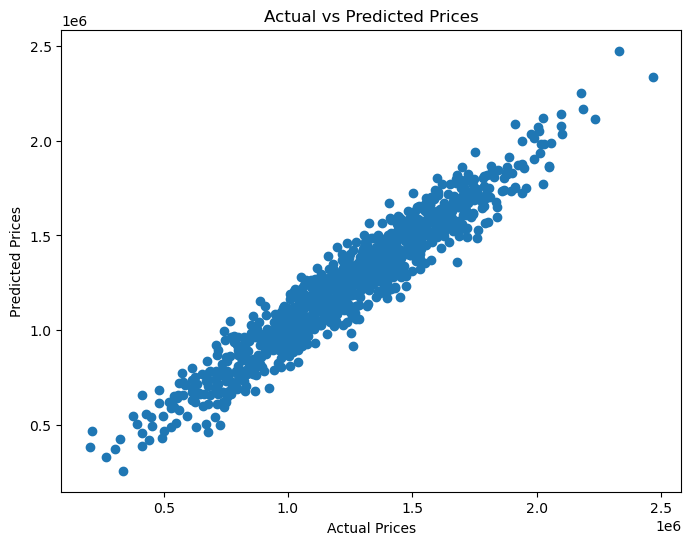

In [18]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

In [19]:
residuals = y_test - y_pred

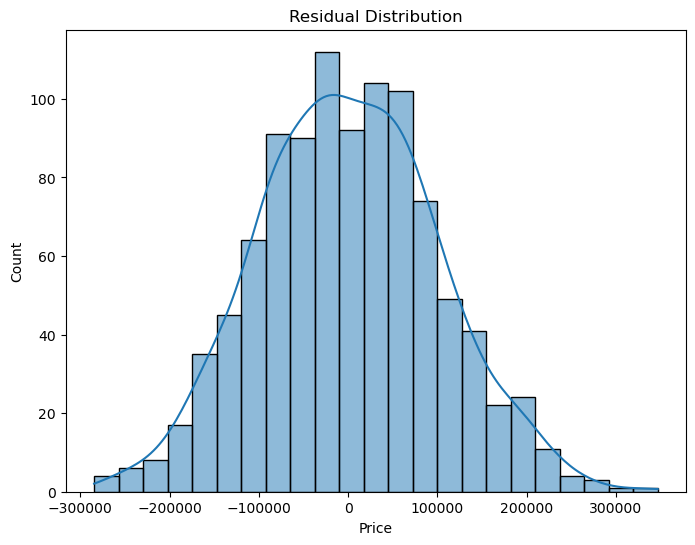

In [20]:
plt.figure(figsize=(8,6))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

In [21]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
coefficients.head()

,Feature,Coefficient
0,Avg. Area Income,21.652206
1,Avg. Area House Age,164666.480722
2,Avg. Area Number of Rooms,119624.012232
3,Avg. Area Number of Bedrooms,2440.377611
4,Area Population,15.270313


In [22]:
import pickle
with open("house_price_model.pkl", "wb") as file:
    pickle.dump(model, file)

In [23]:
results.to_csv("prediction_results.csv", index=False)